# Fine-Tuning Across Modalities

This notebook covers fine-tuning across text, image, audio, and video all through the domain of chess.

The recipes we'll cover stay more or less consistent across data in pairs (e.g. instruction and response), a base model, an adapter, and some evals. What changes per modality is what a pair means, for example, how much data it takes to make a useful model and how the process may fail (and it will most-likely).

There are accompanying projects that can be found in the repo but you do not need them to complete this notebook.

Cells that need an API key or a heavy dependency check first and tell you what to set instead of erroring.

In [60]:
import importlib.util
import json
import os
import chess
from rich import print
from pprint import pprint
import httpx
import numpy as np

In [61]:
def has(pkg: str) -> bool:
    return importlib.util.find_spec(pkg) is not None

CAPS = {
    "openai_key": bool(os.environ.get("OPENAI_API_KEY")),
    "fal_key": bool(os.environ.get("FAL_KEY")),
    "torch": has("torch") and has("transformers"),
    "flax": has("flax"),
    "modal": has("modal"),
    "imageio": has("imageio"),
}
rows = "\n".join(
    f"| {name} | {'yes' if ok else 'no'} |"
    for name, ok in [
        ("OPENAI_API_KEY (opponent, mapping, judge)", CAPS["openai_key"]),
        ("FAL_KEY (image and video generation)", CAPS["fal_key"]),
        ("torch + transformers (local audio)", CAPS["torch"]),
        ("flax (live JAX training)", CAPS["flax"]),
        ("modal (GPU sandbox)", CAPS["modal"]),
    ]
)

print(f"**What runs on this machine right now:**\n\n| capability | ready |\n|---|---|\n{rows}")

In [62]:
print('hey')

## 1. Why chess

AI has beaten grandmasters for decades and chess has never been more popular. It is the perfect fine-tuning domain for for the simple fact that the environment can validate every action. Meaning, a move is legal or it is not, python-chess decides in microseconds, and no human labeler required. These properties give us free supervision for SFT and a free reward signal for RL. If you don't know what these mean, that's okay we'll go over them in a little bit.

There is a personal angle with this example (wether you like chess or not), which is that our in-session games become a dataset we can use and we can also give it a unique angle later where everyone can mould their own instructor to their preference. Mine should teach me to win while capturing as few pieces as possible.

## 2. Game Mechanics

There are many ways of representing a chess board the plays in a game, but the most common ones are:

- **PGN:** Portable Game Notation records the **game as a sequence of moves using Standard Algebraic Notation (SAN)**, usually human-readable, like `1. e4 e5 2. Nf3 Nc6 3. Bb5`. It is great for storing full games, openings, annotations, and results. The model or program must replay the moves to know the current board.

- **FEN:** Forsyth-Edwards Notation records the **current board state in one line**, including pieces, side to move, castling rights, en passant, and move counters. It is ideal for training rows like `current position -> best move`, because the model does not need to reconstruct the position from history.

- **Board tensor / array:** A program represents the board as structured data, often an `8x8` array or tensor with channels for piece types, color, turn, castling, and other state. This is best for custom ML models because it avoids text parsing and gives the model the board directly.

There is also something called **Universal Chess Interface**. It is a protocol chess engines use to communicate with graphical user interfaces, and its move notation is very concise, for example, source square plus target square would be represented as `e2e4`, `g1f3`, or `e7e8q` for promotion to queen. Unlike SAN, UCI does not include human hints like check, capture, or piece name. It just says exactly what square a piece moves from and to, which makes it much easier for models, datasets, and code but hard to keep in mind or noticed that the game finished if you're not directly seeing it in a GUI.

In Python, we have a nice package called `python-chess` that we can use to visualise a board and track a game. You pip or uv install it with `uv pip install chess` in your virtual env.

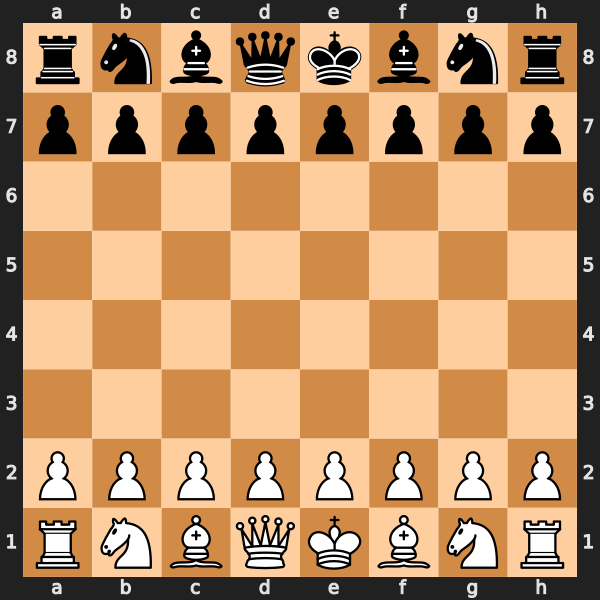

In [3]:
import chess.svg

game_board = chess.Board()
chess.svg.board(board=game_board, size=600)

You can also use `game_board` directly and the svg will be displayed in a cell at a smaller scale.

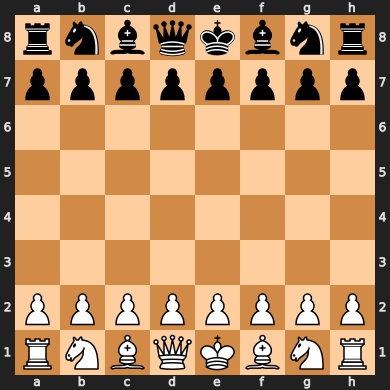

In [4]:
game_board

Without doing anything, you can get the current state of the board in fen notation with the `.fen()` method.

In [6]:
game_board.fen()

'rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1'

**FEN** means **Forsyth-Edwards Notation**.

It is a compact string that describes a chess position.

Starting board:

```text
rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
```

It has **6 fields**:

```text
[piece placement] [turn] [castling] [en passant] [halfmove clock] [fullmove number]
```

### 1. Piece placement

```text
rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR
```

Ranks go from **8 to 1**.

Letters are pieces:

```text
K king
Q queen
R rook
B bishop
N knight
P pawn
```

Uppercase means white. Lowercase means black.

Numbers mean empty squares.

Example:

```text
8
```

means one completely empty rank.

```text
3k4
```

means:

```text
3 empty squares, black king, 4 empty squares
```

### 2. Whose turn

```text
w
```

White to move.

```text
b
```

Black to move.

### 3. Castling rights

```text
KQkq
```

White can castle king-side and queen-side. Black can castle king-side and queen-side.

If nobody can castle:

```text
-
```

### 4. En passant target

```text
-
```

No en passant available.

Example:

```text
e3
```

Means en passant may be possible on e3.

### 5. Halfmove clock

```text
0
```

Number of halfmoves since the last pawn move or capture. Used for the 50-move draw rule.

### 6. Fullmove number

```text
1
```

Starts at 1 and increments after Black moves.

## Why FEN matters

Instead of giving the model the whole game:

```text
1. e4 e5 2. Nf3 Nc6 ...
```

you give it the current board directly:

```json
{
  "fen": "r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 2 3",
  "target_move": "f1b5"
}
```

So the model does not need to reconstruct the board from history.

Important caveat: **FEN captures the current position, but not the full repetition history.** So it is enough for move generation and most training rows, but not perfect for detecting threefold repetition without extra history.


PGN has no information until the game begins so there is nothing to show until then.

You might be wondering what is the point between the two then. The best way to frame it is that with FEN we can teach a model about the best move, including legal ones, given any type of board arrangement, but it misses what happened in order to get to that situation.

PGN, in contrast, shows the model the whole game up until that point. Let's by representing a famous play called the Ruy Lopez.

The Ruy Lopez is also called the Spanish Opening, and it is one of the oldest and most respected chess openings for White. It starts with the moves `1. e4 e5 2. Nf3 Nc6 3. Bb5`. White develops the bishop to attack the knight defending Black's e5-pawn, putting immediate pressure on Black's center without overextending.

[Event "EuroSciPy Chess Studio"]
[Site "?"]
[Date "????.??.??"]
[Round "?"]
[White "Ramon"]
[Black "You"]
[Result "*"]

1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-O *

A game to work with. 9 plies of a Ruy Lopez, ending here:


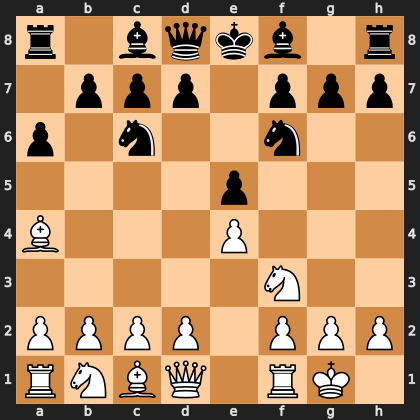

In [7]:
# import chess
import chess.pgn
# import chess.svg

# from IPython.display import SVG, display

# # A scripted Ruy Lopez so the notebook is deterministic without files or API keys.
game_sans = ["e4", "e5", "Nf3", "Nc6", "Bb5", "a6", "Ba4", "Nf6", "O-O"]

game_board = chess.Board()
game_records = []

pgn_game = chess.pgn.Game()
pgn_game.headers["Event"] = "EuroSciPy Chess Studio"
pgn_game.headers["White"] = "Ramon"
pgn_game.headers["Black"] = "You"
pgn_game.headers["Result"] = "*"

node = pgn_game

for ply, san in enumerate(game_sans, start=1):
    legal_before = [game_board.san(m) for m in game_board.legal_moves]

    move = game_board.push_san(san)
    node = node.add_variation(move)

    game_records.append(
        {
            "ply": ply,
            "san": san,
            "uci": move.uci(),
            "legal_moves_before": legal_before,
            "is_check": game_board.is_check(),
            "is_checkmate": game_board.is_checkmate(),
        }
    )

print(pgn_game)

print(
    f"\nA game to work with. {len(game_records)} plies of a "
    "Ruy Lopez, ending here:"
)

board_svg = chess.svg.board(
    board=game_board,
    size=420,
)

# display(SVG(
board_svg
# ))

### Rules Recap

Chess is a two-player game on an 8 by 8 board. White moves first, then players alternate one move at a time. The goal is to checkmate the opponent’s king, which means the king is under attack and has no legal move, block, or capture that can save it.

Each piece moves differently. The king moves one square in any direction. The queen moves any distance horizontally, vertically, or diagonally. Rooks move horizontally or vertically. Bishops move diagonally. Knights move in an L shape and can jump over pieces. Pawns move forward one square, optionally two from their starting square, and capture diagonally.

A move is legal only if it does not leave your own king in check. If your king is attacked, you must respond to that threat immediately. You can escape check by moving the king, capturing the attacking piece, or blocking the attack, unless the attacker is a knight or adjacent piece where blocking is impossible.

There are three special rules worth knowing. Castling moves the king and rook together if neither has moved, the path is clear, and the king does not move through check. En passant lets a pawn capture another pawn that has just advanced two squares as if it had moved one. Promotion happens when a pawn reaches the final rank, usually becoming a queen.

Games can also end without checkmate. A player can resign. The game can draw by stalemate, repetition, the fifty-move rule, insufficient material, or agreement. Stalemate means the player to move is not in check but has no legal moves. This is why chess is annoying in a productive way: winning is not enough; you must win legally.

### Gotcha's of Each Method

**PGN is a game log, not a board state.**
To know the current board, you must replay every move from the start or from a custom FEN header.

**SAN moves are contextual.**
`Nf3` only makes sense if you know the current board. You cannot parse SAN reliably without the board position at that moment.

**FEN is a snapshot, not a full game.**
It gives the current position, turn, castling rights, en passant target, and counters, but it does **not** preserve full move history.

**FEN does not fully capture repetition history.**
Threefold repetition needs historical positions. FEN alone is not enough.

**Castling rights matter.**
Two boards can look identical but have different castling rights. Their legal moves differ.

**En passant is easy to mishandle.**
The FEN en passant field may look irrelevant, but it can affect legal moves immediately after a two-square pawn push.

**Move counters matter for draw rules.**
The halfmove clock is needed for the 50-move rule. Often ignored in training, but not technically disposable.

**For ML targets, UCI is easier than SAN.**
Use `e2e4`, `g1f3`, `e7e8q` as the target move. SAN is nicer for humans, but UCI is simpler and less ambiguous.

Best training row:

```json
{
  "fen_before": "...",
  "legal_moves": ["e2e4", "g1f3"],
  "target_move": "e2e4"
}
```

Best rule: **store PGN for the story, FEN for the state, UCI for the model target.**

In [8]:
# A scripted Ruy Lopez so the notebook is deterministic without keys.
game_sans = ["e4", "e5", "Nf3", "Nc6", "Bb5", "a6", "Ba4", "Nf6", "O-O"]
game_records = []
for san in game_sans:
    fen_before = game_board.fen()
    legal_before = [m.uci() for m in game_board.legal_moves]
    move = game_board.push_san(san)
    game_records.append(
        {
            "san": san,
            "uci": move.uci(),
            "fen_before": fen_before,
            "fen_after": game_board.fen(),
            "legal_moves_before": legal_before,
            "is_check": game_board.is_check(),
            "is_checkmate": game_board.is_checkmate(),
        }
    )

mo.md(
    f"A game to work with. {len(game_records)} plies of a "
    f"Ruy Lopez, ending here:\n\n```\n{game_board.unicode(invert_color=True)}\n```\n\n"
    "Every row of training data in this section comes from this game, "
    "the same way the app builds rows from yours."
)

IllegalMoveError: illegal san: 'e4' in r1bqkb1r/1ppp1ppp/p1n2n2/4p3/B3P3/5N2/PPPP1PPP/RNBQ1RK1 b kq - 3 5

In [9]:
import io
import chess
import chess.pgn

# A scripted Ruy Lopez so the notebook is deterministic without keys.
game_sans = ["e4", "e5", "Nf3", "Nc6", "Bb5", "a6", "Ba4", "Nf6", "O-O"]

game_board = chess.Board()
game_records = []

# Build a PGN game object as we play through the scripted moves.
pgn_game = chess.pgn.Game()
pgn_game.headers["Event"] = "EuroSciPy Chess Studio"
pgn_game.headers["White"] = "Workshop Player"
pgn_game.headers["Black"] = "Workshop Opponent"
pgn_game.headers["Result"] = "*"

node = pgn_game

for ply, san in enumerate(game_sans, start=1):
    fen_before = game_board.fen()
    legal_before = [m.uci() for m in game_board.legal_moves]

    # Parse SAN before pushing, while the board is still in the right state.
    move = game_board.parse_san(san)
    normalized_san = game_board.san(move)

    game_board.push(move)
    node = node.add_variation(move)

    game_records.append(
        {
            "ply": ply,
            "san": normalized_san,
            "uci": move.uci(),
            "fen_before": fen_before,
            "fen_after": game_board.fen(),
            "legal_moves_before": legal_before,
            "is_check": game_board.is_check(),
            "is_checkmate": game_board.is_checkmate(),
        }
    )

# Export the game as PGN text.
pgn_text = pgn_game.accept(
    chess.pgn.StringExporter(headers=True, variations=True, comments=True)
)

print(pgn_text)

print(
    f"A game to work with. {len(game_records)} plies of a "
    f"Ruy Lopez, ending here:\n\n```\n{game_board.unicode(invert_color=True)}\n```\n\n"
    "Every row of training data in this section comes from this game, "
    "the same way the app builds rows from yours."
)

# Read the PGN back and replay it.
loaded_game = chess.pgn.read_game(io.StringIO(pgn_text))
replay_board = loaded_game.board()

for move in loaded_game.mainline_moves():
    print(replay_board.san(move), replay_board.fen())
    replay_board.push(move)

[Event "EuroSciPy Chess Studio"]
[Site "?"]
[Date "????.??.??"]
[Round "?"]
[White "Workshop Player"]
[Black "Workshop Opponent"]
[Result "*"]

1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-O *
A game to work with. 9 plies of a Ruy Lopez, ending here:

```
♖ ⭘ ♗ ♕ ♔ ♗ ⭘ ♖
⭘ ♙ ♙ ♙ ⭘ ♙ ♙ ♙
♙ ⭘ ♘ ⭘ ⭘ ♘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ♙ ⭘ ⭘ ⭘
♝ ⭘ ⭘ ⭘ ♟ ⭘ ⭘ ⭘
⭘ ⭘ ⭘ ⭘ ⭘ ♞ ⭘ ⭘
♟ ♟ ♟ ♟ ⭘ ♟ ♟ ♟
♜ ♞ ♝ ♛ ⭘ ♜ ♚ ⭘
```

Every row of training data in this section comes from this game, the same way the app builds rows from yours.
e4 rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
e5 rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1
Nf3 rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2
Nc6 rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQKB1R b KQkq - 1 2
Bb5 r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 2 3
a6 r1bqkbnr/pppp1ppp/2n5/1B2p3/4P3/5N2/PPPP1PPP/RNBQK2R b KQkq - 3 3
Ba4 r1bqkbnr/1ppp1ppp/p1n5/1B2p3/4P3/5N2/PPPP1PPP/RNBQK2R w KQkq - 0 4
Nf6 r1bqkbnr/1ppp1ppp/p1n5/4p3/B3P3/5

In [10]:
def compute_reward(*, legal: bool, is_check: bool, is_checkmate: bool) -> int:
    if not legal:
        return -1
    if is_checkmate:
        return 10
    if is_check:
        return 2
    return 1

def is_legal_move(fen: str, uci: str) -> bool:
    board = chess.Board(fen)
    try:
        return chess.Move.from_uci(uci) in board.legal_moves
    except ValueError:
        return False

In [11]:
start = chess.STARTING_FEN
mo.md(
    "### The reward function\n\n"
    "SFT teaches the model what good answers look like. RL teaches it "
    "what good actions do. Chess prices actions for free:\n\n"
    f"- illegal (e2e5 from the start): **{compute_reward(legal=is_legal_move(start, 'e2e5'), is_check=False, is_checkmate=False):+d}**\n"
    f"- legal quiet move (e2e4): **{compute_reward(legal=is_legal_move(start, 'e2e4'), is_check=False, is_checkmate=False):+d}**\n"
    "- check: **+2**, checkmate: **+10**\n\n"
    "Four lines of Python. That is the entire reward model. Envy your "
    "colleagues in robotics later."
)

_md()

In [12]:
from rich import print
from rich.markdown import Markdown
from pprint import pprint

In [13]:
def format_pgn_prefix(sans: list[str]) -> str:
    parts = []
    for i, san in enumerate(sans):
        parts.append(f"{i // 2 + 1}. {san}" if i % 2 == 0 else san)
    return " ".join(parts)

def build_dataset_rows(prior_sans, record) -> list[dict]:
    reward = compute_reward(
        legal=True, is_check=record["is_check"], is_checkmate=record["is_checkmate"]
    )
    return [
        {"shape": "pgn_prefix_to_move", "payload": {"prefix": format_pgn_prefix(prior_sans), "target_san": record["san"]}},
        {"shape": "fen_to_move", "payload": {"fen": record["fen_before"], "target_uci": record["uci"]}},
        {"shape": "fen_legal_moves_to_move", "payload": {"fen": record["fen_before"], "legal_moves": record["legal_moves_before"], "target_uci": record["uci"]}},
        {"shape": "board_tensor_to_move_class", "payload": {"tensor_shape": [8, 8, 12], "target_move_class": record["uci"], "note": "the serious supervised path: 12 binary planes, not a string"}},
        {"shape": "policy_value_to_move", "payload": {"policy_target": {u: (1.0 if u == record["uci"] else 0.0) for u in record["legal_moves_before"][:6]}, "value_target": reward / 10, "note": "policy over legal moves plus a scalar value, the engine path"}},
        {"shape": "rl_trajectory", "payload": {"state_fen": record["fen_before"], "action_uci": record["uci"], "reward": reward, "next_state_fen": record["fen_after"], "done": False}},
    ]

all_rows = []
sans_so_far = []
for rec in game_records:
    all_rows.extend(build_dataset_rows(sans_so_far, rec))
    sans_so_far.append(rec["san"])

In [14]:
print(
    "### One move, six dataset shapes\n\n"
    "The same position encoded the way each training approach eats it. "
    f"Our {len(game_records)}-ply game just became **{len(all_rows)} rows**. "
    "The first move, all six ways:\n\n"
    "\n"
    + "\n".join(json.dumps({r['shape']: r['payload']}, default=str)[:170] for r in all_rows[:6])
    + "\n\n\nSame game. Six framings. Same recipe, different results starts here."
)

### One move, six dataset shapes

The same position encoded the way each training approach eats it. Our 9-ply game just became **54 rows**. The first
move, all six ways:


{"pgn_prefix_to_move": {"prefix": "", "target_san": "e4"}}
{"fen_to_move": {"fen": "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1", "target_uci": "e2e4"}}
{"fen_legal_moves_to_move": {"fen": "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1", "legal_moves": 
["g1h3", "g1f3", "b1c3", "b1a3", "h2h3", "g2g3", "f2f3", "e
{"board_tensor_to_move_class": {"tensor_shape": [8, 8, 12], "target_move_class": "e2e4", "note": "the serious 
supervised path: 12 binary planes, not a string"}}
{"policy_value_to_move": {"policy_target": {"g1h3": 0.0, "g1f3": 0.0, "b1c3": 0.0, "b1a3": 0.0, "h2h3": 0.0, 
"g2g3": 0.0}, "value_target": 0.1, "note": "policy over legal
{"rl_trajectory": {"state_fen": "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1", "action_uci": "e2e4", 
"reward": 1, "next_state_fen": "rnbqkbnr/pppppppp/8/8/4P


Same game. Six framings. Same recipe, different results starts here.

In [15]:
PROMPT_TEMPLATE = (
    "You are a chess engine assistant.\n\n"
    "Position (FEN): {fen}\n"
    "Legal moves (UCI): {legal_moves}\n\n"
    "Return exactly one move from the legal moves list, in UCI format.\n"
    'Respond with JSON: {{"move": "<uci>"}}'
)

from jinja2 import Template

CHAT_TEMPLATE = Template(
    "{% for message in messages %}<|{{ message.role }}|>\n{{ message.content }}\n{% endfor %}<|assistant|>\n"
)
rendered = CHAT_TEMPLATE.render(
    messages=[
        {"role": "system", "content": "You are a chess engine assistant."},
        {"role": "user", "content": "Position (FEN): ..."},
    ]
)
print(
    "### Templates, the part everyone fumbles\n\n"
    "The prompt template is what you write. The **chat template** is "
    "what the tokenizer actually renders, and it is Jinja:\n\n"
)
pprint(rendered)
print("Every model family ships its own. Fine-tune with the wrong one and "
    "the model learns to answer a format nobody sends. This is the "
    "single most common silent failure in text fine-tuning."
)

### Templates, the part everyone fumbles

The prompt template is what you write. The **chat template** is what the tokenizer actually renders, and it is 
Jinja:

('<|system|>\n'
 'You are a chess engine assistant.\n'
 '<|user|>\n'
 'Position (FEN): ...\n'
 '<|assistant|>')


Every model family ships its own. Fine-tune with the wrong one and the model learns to answer a format nobody 
sends. This is the single most common silent failure in text fine-tuning.

In [16]:
os.environ.pop("OPENAI_BASE_URL", None)
os.environ["OPENAI_MODEL"] = "gpt-5.6-luna" 

In [17]:
print(os.environ.get("OPENAI_BASE_URL"), os.environ.get("OPENAI_MODEL"),
      os.environ["OPENAI_API_KEY"][:6])

None gpt-5.6-luna sk-pro

In [18]:
print(os.environ["OPENAI_API_KEY"][:12])   # run this in a fresh cell RIGHT NOW: sk-proj-/sk- good, sk-or- is your answer

sk-proj-Zi9a

In [30]:
import random
import time

import httpx


def llm_chat(messages: list[dict], json_mode: bool = True) -> str:
    base = os.environ.get(
        "OPENAI_BASE_URL",
        "https://api.openai.com/v1",
    ).rstrip("/")

    key = os.environ["OPENAI_API_KEY"]

    body = {
        "model": os.environ.get("OPENAI_MODEL", "gpt-5.6-luna"),
        "reasoning_effort": "medium",
        "messages": messages,
    }

    if json_mode:
        body["response_format"] = {"type": "json_object"}

    with httpx.Client(timeout=120.0) as client:
        for attempt in range(3):
            response = client.post(
                f"{base}/chat/completions",
                headers={
                    "Authorization": f"Bearer {key}",
                    "Content-Type": "application/json",
                },
                json=body,
            )

            # Some models may reject response_format.
            if response.status_code == 400 and "response_format" in body:
                body.pop("response_format")
                continue

            if response.status_code == 200:
                return response.json()["choices"][0]["message"]["content"]

            request_id = response.headers.get("x-request-id")

            # One or two retries for apparently transient failures.
            retryable = (
                response.status_code == 401
                or response.status_code == 429
                or response.status_code >= 500
            )

            if not retryable or attempt == 2:
                raise RuntimeError(
                    f"{response.status_code} from {response.request.url}; "
                    f"attempt={attempt + 1}; "
                    f"request_id={request_id}; "
                    f"body={response.text[:400]}"
                )

            delay = (2**attempt) + random.uniform(0, 0.25)
            time.sleep(delay)

    raise RuntimeError("Unreachable")

def parse_move_reply(text: str) -> str | None:
    try:
        _move = json.loads(text.strip().strip("`").removeprefix("json")).get("move", "")
    except json.JSONDecodeError:
        return None
    return _move.strip().lower() or None



In [31]:
import httpx, os
base = os.environ.get("OPENAI_BASE_URL", "https://api.openai.com/v1").rstrip("/")
r = httpx.post(
    f"{base}/chat/completions",
    headers={"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}"},
    json={"model": os.environ.get("OPENAI_MODEL", "gpt-5.6-luna"), "reasoning_effort": "medium",
          "messages": [{"role": "user", "content": "say ok"}]},
    timeout=60,
)
print(r.request.url)
print(r.status_code)
print(r.text[:600])

https://api.openai.com/v1/chat/completions

200

{
  "id": "chatcmpl-E31Hia8pkzPw9XDqKdAeT0Vl9a1aV",
  "object": "chat.completion",
  "created": 1784388630,
  "model": "gpt-5.6-luna",
  "choices": [
    {
      "index": 0,
      "message": {
        "role": "assistant",
        "content": "ok",
        "refusal": null,
        "annotations": []
      },
      "finish_reason": "stop"
    }
  ],
  "usage": {
    "prompt_tokens": 8,
    "completion_tokens": 4,
    "total_tokens": 12,
    "prompt_tokens_details": {
      "cached_tokens": 0,
      "cache_write_tokens": 0,
      "audio_tokens": 0
    },
    "completion_tokens_details": {
      "re

In [32]:
llm_game_log = []
if CAPS["openai_key"]:
    board = chess.Board()
    for ply in range(4):
        legal = [m.uci() for m in board.legal_moves]
        reply = llm_chat(
            [
                {"role": "system", "content": "You play chess. JSON only."},
                {"role": "user", "content": PROMPT_TEMPLATE.format(fen=board.fen(), legal_moves=", ".join(legal))},
            ]
        )
        uci = parse_move_reply(reply)
        legal_choice = uci in legal
        reward = compute_reward(legal=legal_choice, is_check=False, is_checkmate=False)
        llm_game_log.append(f"ply {ply + 1}: model played `{uci}`, reward {reward:+d}")
        if not legal_choice:
            llm_game_log.append("the environment caught it. The board does not move.")
            break
        board.push_uci(uci)
    body = "\n".join(f"- {line}" for line in llm_game_log)
    out = print(f"**The model plays itself for four plies:**\n\n{body}")
else:
    out = print("*Skipped: no OPENAI_API_KEY. The model would play here, and every illegal choice would earn -1 live.*")


out
# mo.vstack(
#     [
#         out,
#         mo.md(
#             "In the whiteboard app this is a timed match: five minutes on "
#             "the clock by default, thirty at most. Starting over counts as "
#             "a loss, and so does the flag falling. The Duolingo rule: "
#             "quitting has a price, so people stop quitting, so the dataset "
#             "keeps growing."
#         ),
#     ]
# )

**The model plays itself for four plies:**

- ply 1: model played `g1f3`, reward +1
- ply 2: model played `g8f6`, reward +1
- ply 3: model played `c2c4`, reward +1
- ply 4: model played `e7e5`, reward +1

In [33]:
real_world_maps = []

if CAPS["openai_key"]:
    for rec in [game_records[1], game_records[4]]:
        reply = llm_chat(
            [
                {
                    "role": "system",
                    "content": (
                        "You are a terse chess commentator who maps chess "
                        "positions to everyday scenarios. Return JSON only."
                    ),
                },
                {
                    "role": "user",
                    "content": (
                        f"Position after {rec['san']} "
                        f"(FEN: {rec['fen_after']}). "
                        'Return JSON with this exact structure: '
                        '{"assessment": "...", "real_world": "..."}'
                    ),
                },
            ]
        )

        try:
            parsed = json.loads(reply)
        except json.JSONDecodeError as exc:
            print(
                f"Could not parse response for {rec['san']}: {exc}\n"
                f"Raw response: {reply}"
            )
            continue

        real_world_maps.append((rec["san"], parsed))

    lines = "\n".join(
        (
            f"- after **{san}**: "
            f"{mapping.get('assessment', '')} "
            f"*{mapping.get('real_world', '')}*"
        )
        for san, mapping in real_world_maps
    )

    out2 = mo.md(
        "### The unique angle: games as life\n\n"
        f"{lines}\n\n"
        "A hundred of these mappings is a dataset nobody else has. "
        "That, not the chess engine, is what makes your fine-tune yours."
    )
else:
    out2 = mo.md(
        "### The unique angle: games as life\n\n"
        "*Skipped: no OPENAI_API_KEY.* "
        "With a key, each position gets mapped to an everyday scenario "
        "(the pinned knight as the colleague who cannot say no). "
        "A hundred such rows is the dataset nobody else has."
    )

out2

_md()

In [34]:
from pathlib import Path

sft_rows = [
    {
        "prompt": PROMPT_TEMPLATE.format(fen=r["payload"]["fen"], legal_moves=", ".join(r["payload"]["legal_moves"])),
        "completion": json.dumps({"move": r["payload"]["target_uci"]}),
    }
    for r in all_rows
    if r["shape"] == "fen_legal_moves_to_move"
]

# Bridge to the app: prefer the file the Export dataset button writes.
sft_path = Path("data/processed/text/chess_sft.jsonl")
if sft_path.is_file():
    sft_rows = [json.loads(line) for line in sft_path.read_text().strip().split("\n")]
    source = f"loaded **{len(sft_rows)} rows from the app's export** at `{sft_path}`"
else:
    sft_path = Path(os.environ.get("TMPDIR", "/tmp")) / "chess_sft.jsonl"
    sft_path.write_text("\n".join(json.dumps(r) for r in sft_rows) + "\n")
    source = f"wrote **{len(sft_rows)} rows** from the scripted game to `{sft_path}`"

mo.md(
    f"### Export: the file every trainer loads\n\nprompt/completion JSONL, {source}. "
    "The Unsloth run, the Axolotl config, and the JAX loop below all "
    "point at this one file. Play on the whiteboard, train here."
)

_md()

In [35]:
legal_rate = 1.0  # scripted game: every recorded move was legal by construction
json_ok = sum(
    1
    for r in all_rows
    if r["shape"] == "fen_legal_moves_to_move"
    and parse_move_reply(json.dumps({"move": r["payload"]["target_uci"]}))
)
json_total = sum(1 for r in all_rows if r["shape"] == "fen_legal_moves_to_move")
mo.md(
    "### Evals before training, not after\n\n"
    f"- legal move rate: **{legal_rate:.2f}** (the metric the model opponent gets judged on)\n"
    f"- valid JSON rate: **{json_ok / json_total:.2f}**\n"
    "- centipawn loss and mate-in-one need Stockfish: "
    "`chess.engine.SimpleEngine.popen_uci('stockfish')`, then "
    "`engine.analyse(board, limit)` per position. Install Stockfish and "
    "those two metrics come free.\n\n"
    "If you cannot measure the base model, you cannot claim the "
    "fine-tune helped. Evals are the first cell you write, not the last."
)

_md()

### The training ladder

Five rungs, most to least abstracted. Same dataset every time.

1. **UI**: Unsloth Studio, `unsloth studio -p 8888`. No code,
   live loss curves, GGUF export.
2. **API**: a training endpoint (Thinking Machines and friends).
   Your data leaves the room; your GPU budget does not.
3. **Config**: Axolotl. The run is a YAML file (next cell).
4. **Code that reads like config**: Unsloth or PEFT (cell after).
5. **As low as it goes**: JAX. You write the loss. It runs live
   in this notebook on CPU.

Past SFT: the reward function plus legality checking here is a
minimal RL environment, hand-rolled so it fits on a slide. The
production-grade version of the same idea (env classes, rubrics,
rollouts, GRPO training) is the verifiers library:
github.com/PrimeIntellect-ai/verifiers.

In [36]:
axolotl_yaml = f"""# axolotl train chess-lora.yml    (NVIDIA Ampere+ or AMD only)
base_model: google/gemma-4-E2B-it
load_in_4bit: true
adapter: lora
lora_r: 16
lora_alpha: 32

chat_template: gemma4
datasets:
  - path: {sft_path}
type:
  field_instruction: prompt
  field_output: completion
  format: "{{instruction}}"
  no_input_format: "{{instruction}}"

sequence_len: 2048
micro_batch_size: 1
gradient_accumulation_steps: 4
num_epochs: 1
learning_rate: 0.0002
output_dir: ./outputs/chess-lora
"""
mo.md(f"### Rung 3: the run is a file\n\n```yaml\n{axolotl_yaml}```")

_md()

In [37]:
unsloth_code = f'''from datasets import load_dataset
from trl import SFTConfig, SFTTrainer
from unsloth import FastModel

dataset = load_dataset("json", data_files="{sft_path}", split="train")

model, tokenizer = FastModel.from_pretrained(
model_name="unsloth/gemma-4-E2B-it", max_seq_length=2048, load_in_4bit=True
)
model = FastModel.get_peft_model(model, r=8, lora_alpha=8)

SFTTrainer(
model=model, tokenizer=tokenizer, train_dataset=dataset,
args=SFTConfig(per_device_train_batch_size=1, gradient_accumulation_steps=4,
               max_steps=60, learning_rate=2e-4, output_dir="outputs/chess-lora"),
).train()'''
mo.md(
    "### Rung 4: code that reads like config\n\n"
    f"```python\n{unsloth_code}\n```\n\n"
    "Gemma 4 E2B, 4-bit, LoRA rank 8: fits in 8GB of VRAM. Sixty steps "
    "on a hundred rows is a real, visible fine-tune. Run it on your "
    "GPU, in Unsloth Studio, or in the sandbox two cells down."
)

_md()

_FlexContainerHtml()
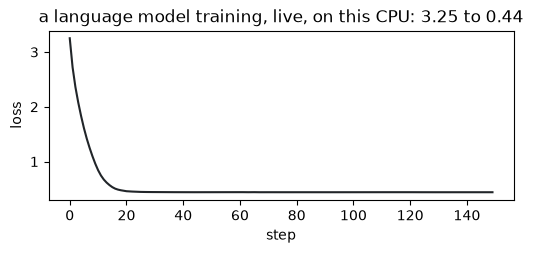

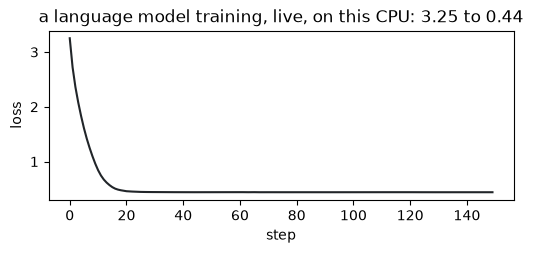

In [43]:
jax_result = None
if CAPS["flax"]:
    import numpy as np
    import optax
    from flax import nnx

    # Tokenize UCI moves: one token per character, tiny vocab.
    vocab = {c: i + 1 for i, c in enumerate("abcdefgh12345678qrbn")}
    seqs = [
        [0] + [vocab[c] for c in r["payload"]["target_uci"]]
        for r in all_rows
        if r["shape"] == "fen_to_move"
    ]
    maxlen = max(len(s) for s in seqs) + 1
    data = np.zeros((len(seqs), maxlen), dtype=np.int32)
    for i, s in enumerate(seqs):
        data[i, : len(s)] = s

    class TinyLM(nnx.Module):
        def __init__(self, vocab, dim=64, rngs=nnx.Rngs(0)):
            self.embed = nnx.Embed(vocab, dim, rngs=rngs)
            self.attn = nnx.MultiHeadAttention(num_heads=4, in_features=dim, decode=False, rngs=rngs)
            self.norm = nnx.LayerNorm(dim, rngs=rngs)
            self.head = nnx.Linear(dim, vocab, rngs=rngs)

        def __call__(self, tokens):
            x = self.embed(tokens)
            x = x + self.attn(self.norm(x), mask=nnx.make_causal_mask(tokens))
            return self.head(x)

    jax_model = TinyLM(vocab=len(vocab) + 1)
    optimizer = nnx.Optimizer(jax_model, optax.adamw(3e-3), wrt=nnx.Param)

    @nnx.jit
    def train_step(model, optimizer, tokens):
        def loss_fn(model):
            logits = model(tokens[:, :-1])
            return optax.softmax_cross_entropy_with_integer_labels(logits, tokens[:, 1:]).mean()

        loss, grads = nnx.value_and_grad(loss_fn)(model)
        optimizer.update(model, grads)
        return loss

    jax_losses = [float(train_step(jax_model, optimizer, data)) for _ in range(150)]
    jax_result = (jax_losses[0], jax_losses[-1])

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 2.2))
    ax.plot(jax_losses, color="#212529")
    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    ax.set_title(f"a language model training, live, on this CPU: {jax_result[0]:.2f} to {jax_result[1]:.2f}")
    out3 = mo.vstack(
        [
            mo.md(
                "### Rung 5: no trainer, no config, just the loss\n\n"
                "A 4-layer-of-code transformer learning the *shape* of UCI "
                "moves from our game, right now, in this cell. It learns the "
                "format in seconds. It does not learn chess. That gap, format "
                "is cheap, competence is not, is the honest one-line summary "
                "of small fine-tunes."
            ),
            fig,
        ]
    )
else:
    out3 = mo.md("### Rung 5: JAX\n\n*Skipped: flax not installed. With it, a tiny transformer trains here, live, on CPU, in seconds.*")
out3

In [ ]:
modal_code = '''import modal

app = modal.App("chess-lora")
image = modal.Image.debian_slim().pip_install("unsloth", "trl", "datasets")

@app.function(gpu="L40S", image=image, timeout=1800,
          secrets=[modal.Secret.from_name("huggingface")])
def train(jsonl: bytes):
open("chess_sft.jsonl", "wb").write(jsonl)
# ... the exact Unsloth cell from above ...

# modal run train_chess.py'''
_configured = CAPS["modal"] and bool(os.environ.get("MODAL_TOKEN_ID"))
mo.md(
    "### Borrowed GPUs: sandboxes\n\n"
    "No GPU in the room? Ship the same code to one. Modal is the "
    "shortest path; Daytona, Docker sandboxes (sbx), and Dify "
    "sandboxes all fit the same hole: your JSONL in, an adapter out.\n\n"
    f"```python\n{modal_code}\n```\n\n"
    + ("Modal is configured on this machine: `modal run` away." if _configured else "*Install modal and run `modal token new` to use this live.*")
)

## 3. Painting Our Pieces (image)

Same recipe. New failure modes.

Diffusion models denoise toward your caption; transformers
predict tokens. Both fine-tune with LoRA, but image adaptation
is far more sensitive to **dataset size and composition** than
text: twenty consistent images beat two hundred sloppy ones.
Providers also quietly rewrite your prompts before generation,
which is why your local results differ from their playground.

The approach menu, each one a different data recipe: text to
image, image to image, image plus text to image, text to SVG,
image to SVG, image editing, image layering.

In [46]:
img_trigger = mo.ui.text(value="wtrclrchess", label="Trigger word")
img_trigger

text()

In [47]:
img_captions = [
    f"a {img_trigger.value} style {piece}, soft watercolor edges, plain background"
    for piece in ["white knight", "black queen", "white bishop", "black rook"]
]
mo.md(
    "**Captions are the dataset.** The trigger word is a new token the "
    "model binds to your style; consistency is what does the binding:\n\n"
    + "\n".join(f"- `{c}`" for c in img_captions)
    + "\n\nHold one aspect ratio too, or the model learns that your style stretches."
)

_md()

In [48]:
import time

def fal_run(model_id: str, payload: dict, timeout: float = 600.0) -> dict:
    """fal queue API: submit, poll the returned urls, fetch."""
    headers = {"Authorization": f"Key {os.environ['FAL_KEY']}"}
    with httpx.Client(timeout=60) as client:
        sub = client.post(f"https://queue.fal.run/{model_id}", headers=headers, json=payload)
        sub.raise_for_status()
        urls = sub.json()
        deadline = time.monotonic() + timeout
        while True:
            status = client.get(urls["status_url"], headers=headers).json()["status"]
            if status == "COMPLETED":
                break
            if status not in ("IN_QUEUE", "IN_PROGRESS") or time.monotonic() > deadline:
                raise RuntimeError(f"fal job state: {status}")
            time.sleep(1)
        return client.get(urls["response_url"], headers=headers).json()

img_url = None
if CAPS["fal_key"]:
    result = fal_run(
        "fal-ai/flux-2/klein/4b",
        {"prompt": img_captions[0], "image_size": "square_hd", "num_images": 1},
    )
    img_url = result["images"][0]["url"]
    out4 = mo.vstack(
        [
            mo.md(f"**FLUX.2 Klein 4B, ~$0.005 and a few seconds:** `{img_captions[0]}`"),
            mo.image(img_url, width=380),
            mo.md("Swap the model id to `fal-ai/flux/schnell` for the cheap-and-fast comparison."),
        ]
    )
else:
    out4 = mo.md("**Generation.** *Skipped: no FAL_KEY.* With one, FLUX.2 Klein 4B renders the first caption here for about half a cent.")
out4

_FlexContainerHtml()

In [49]:
if CAPS["openai_key"] and img_url:
    judge = llm_chat(
        [
            {"role": "user", "content": [
                {"type": "text", "text": f'Judge this image against the caption "{img_captions[0]}". Respond JSON {{"piece_identity": 0-1, "prompt_adherence": 0-1, "note": "..."}}'},
                {"type": "image_url", "image_url": {"url": img_url}},
            ]},
        ]
    )
    try:
        scores = json.loads(judge)
    except json.JSONDecodeError:
        scores = {"note": judge[:200]}
    out5 = mo.md(f"**VLM as judge** (the image evals: piece identity, style consistency, prompt adherence, caption sensitivity, human preference):\n\n```json\n{json.dumps(scores, indent=1)}\n```")
else:
    out5 = mo.md(
        "**Image evals**: piece identity, style consistency, prompt "
        "adherence, caption sensitivity, human preference. The first "
        "four automate with a VLM judge (this cell runs one when both "
        "keys are set); the last one is you, squinting."
    )
out5

_md()

**Training the style**: the same LoRA recipe through Diffusers,
pointed at your drawings.

```bash
accelerate launch train_dreambooth_lora_flux.py   --pretrained_model_name_or_path black-forest-labs/FLUX.2-Klein-4B   --instance_data_dir ./drawings   --instance_prompt "a wtrclrchess style chess piece"   --rank 16 --max_train_steps 800 --learning_rate 1e-4
```

The code ladder repeats: a UI, then stablediffusion.cpp, then
Diffusers. Recognize the shape from the text section. That is
the point.

_FlexContainerHtml()
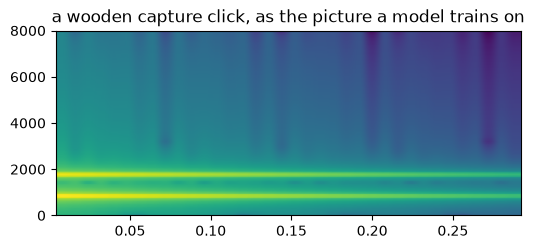

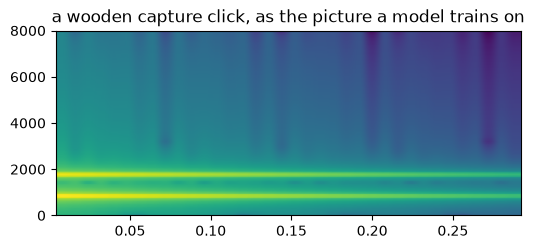

In [50]:
import numpy as np

aud_rate = 16000
t = np.linspace(0, 0.3, int(aud_rate * 0.3), endpoint=False)
aud_wave = np.exp(-t * 30) * (
    0.7 * np.sin(2 * np.pi * 820 * t) + 0.3 * np.sin(2 * np.pi * 1750 * t)
)

import io
import wave as wave_module

buf = io.BytesIO()
with wave_module.open(buf, "wb") as f:
    f.setnchannels(1)
    f.setsampwidth(2)
    f.setframerate(aud_rate)
    f.writeframes((aud_wave * 32767).astype(np.int16).tobytes())
aud_click_wav = buf.getvalue()

import matplotlib.pyplot as plt2

fig2, ax2 = plt2.subplots(figsize=(6, 2.4))
ax2.specgram(aud_wave, Fs=aud_rate, NFFT=256, noverlap=128)
ax2.set_title("a wooden capture click, as the picture a model trains on")
mo.vstack(
    [
        mo.md(
            "## 4. Giving the Board Sound (audio)\n\n"
            "Sound is vibration, audio is its recording, and a spectrogram "
            "turns the recording into an image. From there the recipe splits: "
            "MusicGen predicts audio tokens like an LLM predicts words; "
            "Stable Audio denoises like an image model. Same recipe, "
            "different substrate. First, a capture click from raw sine waves:"
        ),
        mo.audio(aud_click_wav),
        fig2,
    ]
)

In [ ]:
aud_generated = None
if CAPS["torch"]:
    from transformers import pipeline

    synth = pipeline("text-to-audio", "facebook/musicgen-small")
    music = synth(
        "tense chess endgame music, low strings, ticking clock",
        forward_params={"do_sample": True, "max_new_tokens": 256},
    )
    import io as io2

    from scipy.io import wavfile

    buf2 = io2.BytesIO()
    wavfile.write(buf2, rate=music["sampling_rate"], data=music["audio"])
    aud_generated = buf2.getvalue()
    out6 = mo.vstack(
        [
            mo.md("**MusicGen small (0.6B), locally, on this machine.** Five seconds of endgame tension (first run downloads ~2.4GB):"),
            mo.audio(aud_generated),
        ]
    )
else:
    out6 = mo.md(
        "**Local generation.** *Skipped: torch + transformers not "
        "installed.* With them, musicgen-small (0.6B) generates endgame "
        "music right here; stable-audio-open-1.0 does sound effects via "
        "diffusion. The narrator idea (let's get ready to rumble) is a "
        "TTS fine-tune with the same recipe again."
    )
out6

In [ ]:
_wav = aud_generated or aud_click_wav
_samples = np.frombuffer(_wav[44:], dtype=np.int16).astype(np.float32) / 32767
_duration = len(_samples) / (32000 if aud_generated else aud_rate)
_clipping = float(np.mean(np.abs(_samples) > 0.985))
mo.md(
    "**Audio evals, computed on the clip above, not invented:**\n\n"
    f"- duration: **{_duration:.2f}s** (duration error = |target - actual|)\n"
    f"- clipping rate: **{_clipping:.4f}** (samples at the rail)\n"
    "- tag similarity and event recognisability: embed with "
    "panns-inference, cosine against the prompt tags\n"
    "- human preference: still you, still squinting"
)

_FlexContainerHtml()
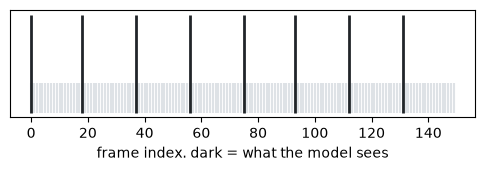

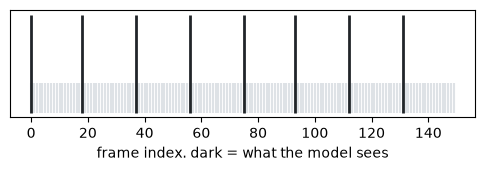

In [52]:
vid_total_frames, vid_samples = 150, 8
vid_indices = [int(i * vid_total_frames / vid_samples) for i in range(vid_samples)]

import matplotlib.pyplot as plt3

fig3, ax3 = plt3.subplots(figsize=(6, 1.4))
ax3.vlines(np.arange(vid_total_frames), 0, 0.3, colors="#dee2e6")
ax3.vlines(vid_indices, 0, 1, colors="#212529", linewidths=2)
ax3.set_yticks([])
ax3.set_xlabel("frame index. dark = what the model sees")
mo.vstack(
    [
        mo.md(
            "## 5. Video of the Real-World Use Case\n\n"
            "The least documented modality. A model cannot eat every frame, "
            f"so it samples: {vid_samples} of {vid_total_frames} frames here, "
            f"**{vid_samples / vid_total_frames:.0%} of the clip**, and it must "
            "hallucinate the rest coherently. Temporal consistency is the "
            "failure mode; compute escalates faster than you expect.\n\n"
            "The plan: take the hundred real-world mapping prompts from the "
            "text section, generate clips with a frontier model, fine-tune "
            "LTX on the result. Distillation by another name."
        ),
        fig3,
    ]
)

In [56]:
vid_url = None
if CAPS["fal_key"]:
    vresult = fal_run(
        "google/gemini-omni-flash",
        {"prompt": "a knight fork winning a queen, top-down wooden chess board, soft light", "duration": 8, 
         # "resolution": "1080p", "fps": 25
        "aspect_ratio": "16:9"},
    )
    vid_url = vresult["video"]["url"]
    out8 = mo.vstack(
        [
            mo.md("**LTX 2.3 fast: six seconds, about $0.24, one long minute.** Say the price out loud, it is the lesson: video costs cents per second where images cost fractions of a cent each."),
            mo.video(vid_url),
        ]
    )
else:
    out8 = mo.md(
        "**Generation.** *Skipped: no FAL_KEY.* With one, LTX 2.3 fast "
        "renders a knight fork here for ~$0.24; swap the id to "
        "`fal-ai/veo3.1/fast` for the frontier comparison at 3x the price. "
        "Temporal flicker measures as mean absolute difference between "
        "consecutive sampled frames: high flicker, broken consistency."
    )
out8

_FlexContainerHtml()

In [54]:
vid_url = vresult["video"]["url"]
out7 = mo.vstack(
    [
        mo.md("**LTX 2.3 fast: six seconds, about $0.24, one long minute.** Say the price out loud, it is the lesson: video costs cents per second where images cost fractions of a cent each."),
        mo.video(vid_url),
    ]
)

In [55]:
out7

_FlexContainerHtml()

## 6. Merging: capabilities without retraining

Once you own several fine-tunes, merging combines them for the
price of an average. mergekit:

```yaml
merge_method: slerp
models:
  - model: outputs/chess-lora        # the player
  - model: outputs/analyst-lora      # the real-world mapper
parameters:
  t: 0.5
```

When it works: adapters trained from the **same base** on
disjoint skills. When it wrecks quality: different bases,
different chat templates, or two adapters fighting over the
same behavior. Merging averages weights, not intentions. Eval
before and after or you merged blind.

## Closing

Training any of these from scratch is expensive, and we get open
models matching closed ones from two years ago, sometimes six
months. The barrier keeps dropping: Karpathy's microchat trains
a GPT in a few hundred lines on consumer hardware, and you just
trained a transformer inside a notebook cell.

As compute gets cheaper, specialisation may matter more than a
ten-point benchmark gap. The recipe you now know four times
over: pairs in, adapter out, eval always. Same recipe,
different results, and the results are yours.

**Resources**: python-chess docs, Unsloth docs (Gemma 4 guide),
Axolotl docs, Flax NNX guide, Diffusers LoRA training scripts,
fal.ai model registry, mergekit, marimo, and the workshop repo
this notebook lives in.